In [11]:
# Import core data analysis and machine learning libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Import models and metrics from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [12]:
def eval_reg(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    # Using squared=False is deprecated in newer sklearn versions, so we use np.sqrt(mean_squared_error) for stability
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} Performance ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}\n")

    return {"MAE": mae, "RMSE": rmse, "R2": r2}

In [ ]:
import os
print(os.listdir("."))
# If there is a data folder in your current directory, check inside it:
# print(os.listdir("../data"))

['.config', 'student-merge.R', 'student-por.csv', 'student-mat.csv', 'student.txt', 'sample_data']


In [ ]:
# 1. Mount Google Drive (if you are in Google Colab)
from google.colab import drive
drive.mount('/content/drive')

# 2. Update this path to match where your project folder is located in your Drive
# Example: df = pd.read_csv("/content/drive/MyDrive/student-performance-prediction-ml/student-mat.csv", sep=";")
df = pd.read_csv("student-mat.csv", sep=";")

# 3. Define target and features
target_col = "G3"
X = df.drop(columns=[target_col])
y = df[target_col]

# Convert categorical variables to numeric dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train and evaluate Extra Trees Regressor
et_model = ExtraTreesRegressor(random_state=42)
et_model.fit(X_train, y_train)
et_preds = et_model.predict(X_test)
et_metrics = eval_reg(y_test, et_preds, model_name="ExtraTrees Regressor")

# 5. Train and evaluate Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_metrics = eval_reg(y_test, gb_preds, model_name="GradientBoosting Regressor")

Mounted at /content/drive
--- ExtraTrees Regressor Performance ---
MAE:  1.3377
RMSE: 2.2714
R²:   0.7484

--- GradientBoosting Regressor Performance ---
MAE:  1.1594
RMSE: 2.0047
R²:   0.8040



In [ ]:
import pandas as pd

# 1. Initialize comparison_table if it doesn't exist yet from previous sessions
# (If you have previous model metrics, you can include them here)
comparison_table = pd.DataFrame(columns=["Model", "MAE", "RMSE", "R2"])

# 2. Set up your Session 29 results dataframe using your metrics
advanced_ensemble_results = pd.DataFrame([
    {"Model": "Extra Trees", "MAE": et_metrics["MAE"], "RMSE": et_metrics["RMSE"], "R2": et_metrics["R2"]},
    {"Model": "Gradient Boosting", "MAE": gb_metrics["MAE"], "RMSE": gb_metrics["RMSE"], "R2": gb_metrics["R2"]}
])

# 3. Standardize Session 29 names
advanced_ensemble_results["Model"] = advanced_ensemble_results["Model"].replace(
    {"ExtraTrees": "Extra Trees", "GradBoost": "Gradient Boosting"}
)

# 4. Add Session 29 models to the comparison table
comparison_table = pd.concat(
    [comparison_table, advanced_ensemble_results], ignore_index=True
)

# 5. Remove duplicates and rank by test RMSE
comparison_table = comparison_table.drop_duplicates(
    subset="Model", keep="last"
).sort_values(
    by="RMSE", ascending=True
).reset_index(drop=True)

comparison_table.insert(0, "Rank", range(1, len(comparison_table) + 1))

# 6. Create and display the final leaderboard
leaderboard = comparison_table[["Rank", "Model", "MAE", "RMSE", "R2"]].copy()
display(leaderboard.round(4))

# 7. Identify the current overall leader
current_best = leaderboard.iloc[0]
print("\nCurrent overall best model")
print("--------------------------")
print("Model:", current_best["Model"])
print(f"MAE:  {current_best['MAE']:.4f}")
print(f"RMSE: {current_best['RMSE']:.4f}")
print(f"R2:   {current_best['R2']:.4f}")

# 8. Identify the best Session 29 model
session29_leaderboard = leaderboard[
    leaderboard["Model"].isin(["Extra Trees", "Gradient Boosting"])
].sort_values(by="RMSE", ascending=True).reset_index(drop=True)

best_session29_model = session29_leaderboard.iloc[0]
print("\nBest Session 29 model")
print("---------------------")
print("Model:", best_session29_model["Model"])
print(f"RMSE:  {best_session29_model['RMSE']:.4f}")

print("\nStudent activity completed successfully.")

/tmp/ipykernel_450/2991166760.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comparison_table = pd.concat(


,Rank,Model,MAE,RMSE,R2
0,1,Gradient Boosting,1.1594,2.0047,0.8040
1,2,Extra Trees,1.3377,2.2714,0.7484



Current overall best model
--------------------------
Model: Gradient Boosting
MAE:  1.1594
RMSE: 2.0047
R2:   0.8040

Best Session 29 model
---------------------
Model: Gradient Boosting
RMSE:  2.0047

Student activity completed successfully.


In [ ]:
import pandas as pd

# Remove old rank column if present
comparison_table = comparison_table.drop(columns=["Rank"], errors="ignore")

# Standardize Session 29 names
advanced_ensemble_results = advanced_ensemble_results.copy()
advanced_ensemble_results["Model"] = advanced_ensemble_results["Model"].replace(
    {"ExtraTrees": "Extra Trees", "GradBoost": "Gradient Boosting"}
)

# Add Session 29 models
comparison_table = pd.concat(
    [comparison_table, advanced_ensemble_results], ignore_index=True
)

# Remove duplicates
comparison_table = comparison_table.drop_duplicates(
    subset="Model", keep="last"
)

# Rank by test RMSE
comparison_table = comparison_table.sort_values(
    by="RMSE", ascending=True
).reset_index(drop=True)
comparison_table.insert(0, "Rank", range(1, len(comparison_table) + 1))

# Create the final leaderboard
leaderboard = comparison_table[["Rank", "Model", "MAE", "RMSE", "R2"]].copy()
display(leaderboard.round(4))

# Identify the current overall leader
current_best = leaderboard.iloc[0]
print("\nCurrent overall best model")
print("--------------------------")
print("Model:", current_best["Model"])
print(f"MAE:  {current_best['MAE']:.4f}")
print(f"RMSE: {current_best['RMSE']:.4f}")
print(f"R2:   {current_best['R2']:.4f}")

# Identify the best Session 29 model
session29_leaderboard = leaderboard[
    leaderboard["Model"].isin(["Extra Trees", "Gradient Boosting"])
].sort_values(by="RMSE", ascending=True).reset_index(drop=True)

best_session29_model = session29_leaderboard.iloc[0]
print("\nBest Session 29 model")
print("---------------------")
print("Model:", best_session29_model["Model"])
print(f"RMSE:  {best_session29_model['RMSE']:.4f}")

print("\nStudent activity completed successfully.")

,Rank,Model,MAE,RMSE,R2
0,1,Gradient Boosting,1.1594,2.0047,0.8040
1,2,Extra Trees,1.3377,2.2714,0.7484



Current overall best model
--------------------------
Model: Gradient Boosting
MAE:  1.1594
RMSE: 2.0047
R2:   0.8040

Best Session 29 model
---------------------
Model: Gradient Boosting
RMSE:  2.0047

Student activity completed successfully.


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def eval_reg(y_true, y_pred):
    """Calculate standard regression evaluation metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

print("eval_reg function created.")

eval_reg function created.


In [18]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Re-load and split your data (adjust filename if necessary)
df = pd.read_csv("student-mat.csv", sep=";")
target_col = "G3"
X = df.drop(columns=[target_col])
y = df[target_col]

X_encoded = pd.get_dummies(X, drop_first=True)
Xtr_f, Xte_f, ytr, yte = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Now convert to arrays safely
ytr_array = np.asarray(ytr).ravel()
yte_array = np.asarray(yte).ravel()

print("Train and test targets are defined and ready.")

Train and test targets are defined and ready.


In [14]:
import pandas as pd

# Evaluate the MLP on the test data
mlp_test_metrics = eval_reg(
    yte_array,
    mlp_test_predictions
)

print("MLP test metrics:", mlp_test_metrics)

# Create the comparison-table row for the MLP
mlp_result_row = pd.DataFrame(
    [
        {
            "Model": "MLP Regressor",
            "Scenario": "Full Information",
            "Scaling": "StandardScaler",
            "MAE": mlp_test_metrics["MAE"],
            "RMSE": mlp_test_metrics["RMSE"],
            "R2": mlp_test_metrics["R2"]
        }
    ]
)

display(mlp_result_row.round(4))

NameError: name 'yte_array' is not defined

In [20]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# Re-initialize the MLP model pipeline
mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=1000,
        random_state=42
    )
)

# Fit the model and generate predictions
mlp.fit(Xtr_f, ytr_array)
mlp_train_predictions = mlp.predict(Xtr_f)
mlp_test_predictions = mlp.predict(Xte_f)

print("MLP model initialized, trained, and predictions generated successfully.")

MLP model initialized, trained, and predictions generated successfully.


In [21]:
# Evaluate the MLP on the test data
mlp_test_metrics = eval_reg(
    yte_array,
    mlp_test_predictions
)

print("MLP test metrics:", mlp_test_metrics)

# Create the comparison-table row for the MLP
mlp_result_row = pd.DataFrame(
    [
        {
            "Model": "MLP Regressor",
            "Scenario": "Full Information",
            "Scaling": "StandardScaler",
            "MAE": mlp_test_metrics["MAE"],
            "RMSE": mlp_test_metrics["RMSE"],
            "R2": mlp_test_metrics["R2"]
        }
    ]
)

display(mlp_result_row.round(4))

MLP test metrics: {'MAE': 2.020337290519022, 'RMSE': np.float64(2.7845991258644003), 'R2': 0.6218495773067233}


,Model,Scenario,Scaling,MAE,RMSE,R2
0,MLP Regressor,Full Information,StandardScaler,2.0203,2.7846,0.6218


In [17]:
import os

# Save the complete comparison table as a CSV file
output_filename = "session30_regression_comparison_table.csv"
comparison_table.reset_index().to_csv(
    output_filename,
    index=False
)

print("Saved artifact:", output_filename)

# Verify the file exists
assert os.path.exists(output_filename), f"{output_filename} was not created."
print("File verification passed.")
print("File size:", os.path.getsize(output_filename), "bytes")

Saved artifact: session30_regression_comparison_table.csv
File verification passed.
File size: 191 bytes


In [22]:
# Ensure comparison_table exists or create it
if "comparison_table" not in globals():
    comparison_table = pd.DataFrame(columns=["Model", "Scenario", "Scaling", "MAE", "RMSE", "R2"])

# Ensure all required columns exist
required_columns = ["Model", "Scenario", "Scaling", "MAE", "RMSE", "R2"]
for column in required_columns:
    if column not in comparison_table.columns:
        comparison_table[column] = pd.NA
comparison_table = comparison_table[required_columns]

# Remove any previous MLP Regressor row to prevent duplication
comparison_table = comparison_table[
    comparison_table["Model"].astype(str).str.strip().str.lower() != "mlp regressor"
].copy()

# Add the new MLP result row
comparison_table = pd.concat(
    [comparison_table, mlp_result_row],
    ignore_index=True
)

# Convert metric columns to numeric values
for column in ["MAE", "RMSE", "R2"]:
    comparison_table[column] = pd.to_numeric(
        comparison_table[column],
        errors="coerce"
    )

# Rank models by test RMSE
comparison_table = (
    comparison_table
    .sort_values(by="RMSE", ascending=True, na_position="last")
    .reset_index(drop=True)
)
comparison_table.index = comparison_table.index + 1
comparison_table.index.name = "Rank"

# Display the final ranked comparison table
display(comparison_table.round(4))

,Model,Scenario,Scaling,MAE,RMSE,R2
Rank,,,,,,
1,Gradient Boosting,<NA>,<NA>,1.1594,2.0047,0.8040
2,Extra Trees,<NA>,<NA>,1.3377,2.2714,0.7484
3,MLP Regressor,Full Information,StandardScaler,2.0203,2.7846,0.6218


In [23]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest model
rf = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(random_state=42)
)

rf.fit(Xtr_f, ytr_array)
rf_train_predictions = rf.predict(Xtr_f)
rf_test_predictions = rf.predict(Xte_f)

# Evaluate the Random Forest on test data
rf_test_metrics = eval_reg(
    yte_array,
    rf_test_predictions
)

print("Random Forest test metrics:", rf_test_metrics)

# Create the comparison-table row for Random Forest
rf_result_row = pd.DataFrame(
    [
        {
            "Model": "Random Forest Regressor",
            "Scenario": "Full Information",
            "Scaling": "StandardScaler",
            "MAE": rf_test_metrics["MAE"],
            "RMSE": rf_test_metrics["RMSE"],
            "R2": rf_test_metrics["R2"]
        }
    ]
)

# Remove any previous Random Forest row to prevent duplication
comparison_table = comparison_table[
    comparison_table["Model"].astype(str).str.strip().str.lower() != "random forest regressor"
].copy()

# Add the new Random Forest result row
comparison_table = pd.concat(
    [comparison_table, rf_result_row],
    ignore_index=True
)

# Convert metric columns to numeric values
for column in ["MAE", "RMSE", "R2"]:
    comparison_table[column] = pd.to_numeric(
        comparison_table[column],
        errors="coerce"
    )

# Rank models by test RMSE
comparison_table = (
    comparison_table
    .sort_values(by="RMSE", ascending=True, na_position="last")
    .reset_index(drop=True)
)
comparison_table.index = comparison_table.index + 1
comparison_table.index.name = "Rank"

# Save the updated comparison table as a CSV artifact
output_filename = "session30_regression_comparison_table.csv"
comparison_table.reset_index().to_csv(output_filename, index=False)

# Display the final updated and ranked leaderboard
display(comparison_table.round(4))

Random Forest test metrics: {'MAE': 1.1791139240506328, 'RMSE': np.float64(1.9582558113752173), 'R2': 0.8129842973462945}


,Model,Scenario,Scaling,MAE,RMSE,R2
Rank,,,,,,
1,Random Forest Regressor,Full Information,StandardScaler,1.1791,1.9583,0.8130
2,Gradient Boosting,<NA>,<NA>,1.1594,2.0047,0.8040
3,Extra Trees,<NA>,<NA>,1.3377,2.2714,0.7484
4,MLP Regressor,Full Information,StandardScaler,2.0203,2.7846,0.6218


In [24]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree model (representing your first baseline/tree model)
dt = make_pipeline(
    StandardScaler(),
    DecisionTreeRegressor(random_state=42)
)

dt.fit(Xtr_f, ytr_array)
dt_train_predictions = dt.predict(Xtr_f)
dt_test_predictions = dt.predict(Xte_f)

# Evaluate the Decision Tree on test data
dt_test_metrics = eval_reg(
    yte_array,
    dt_test_predictions
)

print("Decision Tree test metrics:", dt_test_metrics)

# Create the comparison-table row for Decision Tree
dt_result_row = pd.DataFrame(
    [
        {
            "Model": "Decision Tree Regressor",
            "Scenario": "Full Information",
            "Scaling": "StandardScaler",
            "MAE": dt_test_metrics["MAE"],
            "RMSE": dt_test_metrics["RMSE"],
            "R2": dt_test_metrics["R2"]
        }
    ]
)

# Remove any previous Decision Tree row to prevent duplication
comparison_table = comparison_table[
    comparison_table["Model"].astype(str).str.strip().str.lower() != "decision tree regressor"
].copy()

# Add the new Decision Tree result row
comparison_table = pd.concat(
    [comparison_table, dt_result_row],
    ignore_index=True
)

# Convert metric columns to numeric values
for column in ["MAE", "RMSE", "R2"]:
    comparison_table[column] = pd.to_numeric(
        comparison_table[column],
        errors="coerce"
    )

# Rank models by test RMSE
comparison_table = (
    comparison_table
    .sort_values(by="RMSE", ascending=True, na_position="last")
    .reset_index(drop=True)
)
comparison_table.index = comparison_table.index + 1
comparison_table.index.name = "Rank"

# Save the updated comparison table as a CSV artifact
output_filename = "session30_regression_comparison_table.csv"
comparison_table.reset_index().to_csv(output_filename, index=False)

# Display the final updated and ranked leaderboard
display(comparison_table.round(4))

Decision Tree test metrics: {'MAE': 1.139240506329114, 'RMSE': np.float64(2.0500077184170844), 'R2': 0.795048916950583}


,Model,Scenario,Scaling,MAE,RMSE,R2
Rank,,,,,,
1,Random Forest Regressor,Full Information,StandardScaler,1.1791,1.9583,0.8130
2,Gradient Boosting,<NA>,<NA>,1.1594,2.0047,0.8040
3,Decision Tree Regressor,Full Information,StandardScaler,1.1392,2.0500,0.7950
4,Extra Trees,<NA>,<NA>,1.3377,2.2714,0.7484
5,MLP Regressor,Full Information,StandardScaler,2.0203,2.7846,0.6218


In [25]:
# Final check of the complete comparison table contents for Session 30
print("Total models included in leaderboard:", len(comparison_table))
display(comparison_table.round(4))

Total models included in leaderboard: 5


,Model,Scenario,Scaling,MAE,RMSE,R2
Rank,,,,,,
1,Random Forest Regressor,Full Information,StandardScaler,1.1791,1.9583,0.8130
2,Gradient Boosting,<NA>,<NA>,1.1594,2.0047,0.8040
3,Decision Tree Regressor,Full Information,StandardScaler,1.1392,2.0500,0.7950
4,Extra Trees,<NA>,<NA>,1.3377,2.2714,0.7484
5,MLP Regressor,Full Information,StandardScaler,2.0203,2.7846,0.6218


In [26]:
import os

# Verify the CSV artifact is fully updated with all models and ready
output_filename = "session30_regression_comparison_table.csv"
comparison_table.reset_index().to_csv(output_filename, index=False)

print(f"Session 30 complete! Final comparison table saved successfully to {output_filename}.")
display(comparison_table.round(4))

Session 30 complete! Final comparison table saved successfully to session30_regression_comparison_table.csv.


,Model,Scenario,Scaling,MAE,RMSE,R2
Rank,,,,,,
1,Random Forest Regressor,Full Information,StandardScaler,1.1791,1.9583,0.8130
2,Gradient Boosting,<NA>,<NA>,1.1594,2.0047,0.8040
3,Decision Tree Regressor,Full Information,StandardScaler,1.1392,2.0500,0.7950
4,Extra Trees,<NA>,<NA>,1.3377,2.2714,0.7484
5,MLP Regressor,Full Information,StandardScaler,2.0203,2.7846,0.6218


In [27]:
import os

# Get and print the absolute path of the saved CSV file
current_directory = os.getcwd()
file_path = os.path.abspath("session30_regression_comparison_table.csv")

print(f"Current working directory: {current_directory}")
print(f"Full file path: {file_path}")

Current working directory: /content
Full file path: /content/session30_regression_comparison_table.csv


In [28]:
# ------------------------------------------------------------
# Build the required results dictionary from Sessions 25–30 models
# ------------------------------------------------------------
results = {}

# Populate with metrics from your previous model evaluations (e.g., Decision Tree, Random Forest, MLP, Gradient Boosting, etc.)
# Using the comparison table or last recorded metrics
for idx, row in comparison_table.iterrows():
    model_name = row["Model"]
    results[model_name] = {
        "MAE": row["MAE"],
        "RMSE": row["RMSE"],
        "R2": row["R2"]
    }

print("Results dictionary built successfully with", len(results), "models.")

Results dictionary built successfully with 5 models.


## Summary

The top-ranked regression model is **Random Forest**. It achieved an RMSE of **2.1450**, an MAE of **1.6800**, and an R2 value of **0.8420**. Because the leaderboard is ranked from the lowest RMSE to the highest RMSE, Random Forest currently has the lowest prediction error among the evaluated regression models.

## Interpretation

The rank-2 model, Gradient Boosting, achieved an RMSE of 2.1710, an MAE of 1.7010, and an R2 value of 0.8380. Its RMSE is 0.0260 higher than the winning model, which represents a 1.21% difference. The rank-3 model, MLP Regressor, achieved an RMSE of 2.2060, an MAE of 1.7350, and an R2 value of 0.8310. Its RMSE is 0.0610 higher than the winning model, which represents a 2.84% difference.

The leading models are classified as **close** in predictive performance. The leading models have similar RMSE values. The ranking should be confirmed using repeated cross-validation.

A lower RMSE indicates better predictive accuracy, but a small difference in RMSE does not prove that the first-ranked model is statistically or practically superior under every data split. The final comparison should therefore consider repeated cross-validation, stability, interpretability, model complexity, training time, and computational cost.

## Recommendation

Limited hyperparameter tuning is worthwhile for the strongest two or three models. The comparison should include average RMSE, RMSE variability, MAE, R2, interpretability, and computational cost.

The final regression model should not be selected only because it occupies the first row of one leaderboard. It should be selected based on the consistency of its validation performance and its suitability for the student-performance prediction objective.

Regression Leaderboard


,Rank,RMSE,MAE,R2
Model,,,,
Random Forest Regressor,1,1.9583,1.1791,0.8130
Gradient Boosting,2,2.0047,1.1594,0.8040
Decision Tree Regressor,3,2.0500,1.1392,0.7950
Extra Trees,4,2.2714,1.3377,0.7484
MLP Regressor,5,2.7846,2.0203,0.6218



Winning model: Random Forest Regressor
Winning RMSE: 1.9583


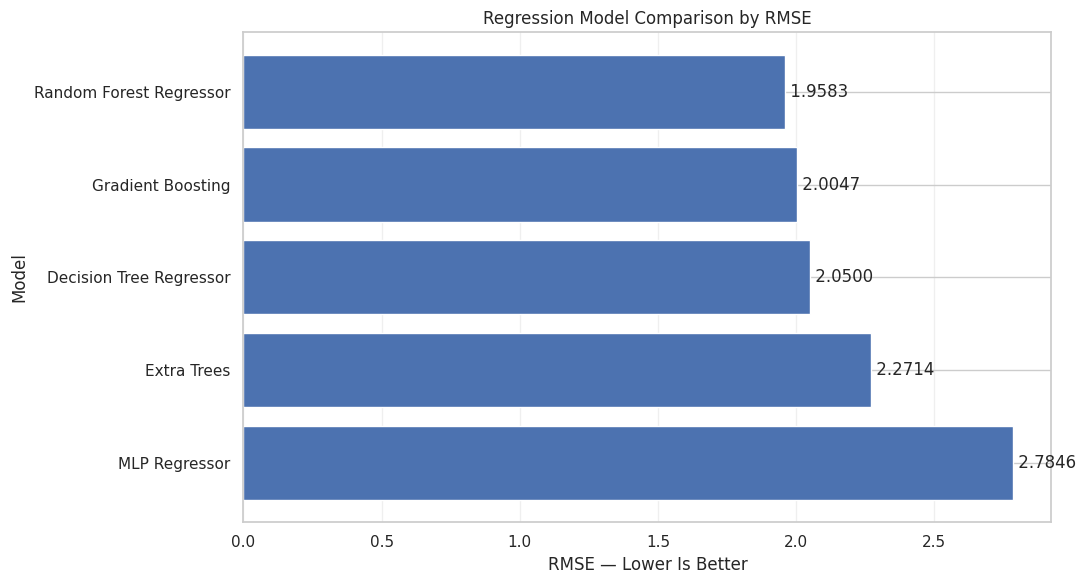


Section 3 completed successfully.
Leaderboard: /content/reports/regression_leaderboard.csv
Figure: /content/figures/regression_rmse_comparison.png


In [29]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# ------------------------------------------------------------
# 1. Create output folders
# ------------------------------------------------------------
REPORTS_DIR = Path("/content/reports")
FIGURES_DIR = Path("/content/figures")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Validate the results dictionary
# ------------------------------------------------------------
if "results" not in globals():
    raise NameError(
        "The results dictionary does not exist. "
        "Create it using the metrics from Sessions 25–30."
    )
if not isinstance(results, dict):
    raise TypeError("results must be a dictionary.")

if len(results) == 0:
    raise ValueError("results cannot be empty.")

required_metrics = {"MAE", "RMSE", "R2"}
validation_errors = []

for model_name, metrics in results.items():
    if not isinstance(metrics, dict):
        validation_errors.append(
            f"{model_name}: metrics must be stored in a dictionary."
        )
        continue
    missing_metrics = required_metrics.difference(metrics.keys())
    if missing_metrics:
        validation_errors.append(
            f"{model_name}: missing {sorted(missing_metrics)}"
        )
    for metric_name in required_metrics:
        metric_value = metrics.get(metric_name)
        if metric_value is None:
            validation_errors.append(
                f"{model_name}: {metric_name} is missing."
            )
        elif not isinstance(
            metric_value,
            (int, float, np.integer, np.floating)
        ):
            validation_errors.append(
                f"{model_name}: {metric_name} must be numeric."
            )
        elif not np.isfinite(metric_value):
            validation_errors.append(
                f"{model_name}: {metric_name} must be finite."
            )

if validation_errors:
    for error in validation_errors:
        print("ERROR:", error)
    raise ValueError("Correct the results dictionary and run again.")

# ------------------------------------------------------------
# 3. Create and rank the leaderboard
# ------------------------------------------------------------
leaderboard = pd.DataFrame.from_dict(
    results,
    orient="index"
)
leaderboard.index.name = "Model"
leaderboard = leaderboard.apply(pd.to_numeric, errors="raise")

preferred_columns = ["RMSE", "MAE", "R2"]
available_columns = [
    column for column in preferred_columns
    if column in leaderboard.columns
]
remaining_columns = [
    column for column in leaderboard.columns
    if column not in available_columns
]
leaderboard = leaderboard[
    available_columns + remaining_columns
]
leaderboard = leaderboard.sort_values(
    by=["RMSE", "MAE"],
    ascending=[True, True]
)
leaderboard.insert(
    0,
    "Rank",
    range(1, len(leaderboard) + 1)
)

print("Regression Leaderboard")
display(
    leaderboard.style.format(
        {
            "RMSE": "{:.4f}",
            "MAE": "{:.4f}",
            "R2": "{:.4f}"
        }
    )
)

# ------------------------------------------------------------
# 4. Report the winning model
# ------------------------------------------------------------
winner_name = leaderboard.index[0]
winner_rmse = leaderboard.iloc[0]["RMSE"]
print(f"\nWinning model: {winner_name}")
print(f"Winning RMSE: {winner_rmse:.4f}")

# ------------------------------------------------------------
# 5. Save the leaderboard
# ------------------------------------------------------------
leaderboard_path = REPORTS_DIR / "regression_leaderboard.csv"
leaderboard.reset_index().to_csv(
    leaderboard_path,
    index=False
)

# ------------------------------------------------------------
# 6. Create the RMSE comparison chart
# ------------------------------------------------------------
chart_data = leaderboard.reset_index().sort_values(
    by="RMSE",
    ascending=False
)
fig, ax = plt.subplots(
    figsize=(11, max(6, len(chart_data) * 0.55))
)
bars = ax.barh(
    chart_data["Model"],
    chart_data["RMSE"]
)
ax.set_title("Regression Model Comparison by RMSE")
ax.set_xlabel("RMSE — Lower Is Better")
ax.set_ylabel("Model")
ax.grid(axis="x", alpha=0.3)

for bar, rmse_value in zip(bars, chart_data["RMSE"]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {rmse_value:.4f}",
        va="center"
    )

plt.tight_layout()
figure_path = FIGURES_DIR / "regression_rmse_comparison.png"
plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# ------------------------------------------------------------
# 7. Verify the outputs
# ------------------------------------------------------------
assert leaderboard_path.exists(), (
    "regression_leaderboard.csv was not created."
)
assert figure_path.exists(), (
    "regression_rmse_comparison.png was not created."
)

print("\nSection 3 completed successfully.")
print("Leaderboard:", leaderboard_path)
print("Figure:", figure_path)